In [23]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
from src.fractal_functions import alpha_fractalize
from src.fractal_activation_N import FractalActivationN

In [24]:
# Base functions f: x, x², x³
identity = lambda x: np.asarray(x, dtype=float)
square   = lambda x: np.asarray(x, dtype=float) ** 2
cube     = lambda x: np.asarray(x, dtype=float) ** 3

# Fractal domain
a, b = 0, 1
n_subintervals = 3
n_iter = 3
alpha = [ 0.9, -0.8, 0.4]

# Base functions g(x) = f(x) + x²(x-b)²
perturbation = lambda x: np.asarray(x, dtype=float)**2 * (np.asarray(x, dtype=float) - b)**2
g_identity = lambda x: identity(x) + perturbation(x)
g_square   = lambda x: square(x) + perturbation(x)
g_cube     = lambda x: cube(x) + perturbation(x)

# Precompute fractal LUTs
identity_fractal = alpha_fractalize(identity, g_identity, a, b, n_subintervals, alpha, n_iter, True)
square_fractal   = alpha_fractalize(square,   g_square,   a, b, n_subintervals, alpha, n_iter, True)
cube_fractal     = alpha_fractalize(cube,     g_cube,     a, b, n_subintervals, alpha, n_iter, True)

# Create FractalActivationN modules
f_relu         = FractalActivationN(identity_fractal, lambda x: x)
f_squared_relu = FractalActivationN(square_fractal,   lambda x: x ** 2)
f_cubic_relu   = FractalActivationN(cube_fractal,     lambda x: x ** 3)

In [25]:
test_values = [0.25]
x = torch.tensor(test_values)

print("f_relu:",         f_relu(x).tolist())
print("f_squared_relu:", f_squared_relu(x).tolist())
print("f_cubic_relu:",   f_cubic_relu(x).tolist())

f_relu: [0.1938735842704773]
f_squared_relu: [0.006402174010872841]
f_cubic_relu: [-0.04047979414463043]


In [26]:
import matplotlib.pyplot as plt

# Generate x values in [-2, 2]
x_vals = torch.linspace(-2, 2, 1600)

# Compute classical activations
classical_relu = torch.clamp(x_vals, min=0)
classical_squared = classical_relu ** 2
classical_cubic = classical_relu ** 3

# Compute fractal activations
with torch.no_grad():
    y_relu = f_relu(x_vals)
    y_squared = f_squared_relu(x_vals)
    y_cubic = f_cubic_relu(x_vals)



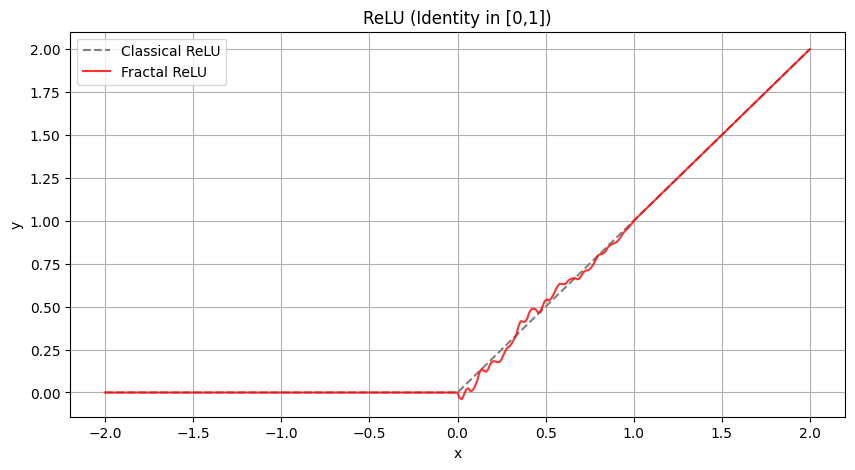

In [27]:
# Plotting
plt.figure(figsize=(10, 5))
    
plt.plot(x_vals.numpy(), classical_relu.numpy(), label='Classical ReLU', color='gray', linestyle='--')
plt.plot(x_vals.numpy(), y_relu.numpy(), label='Fractal ReLU', color='red', alpha=0.8)
plt.title('ReLU (Identity in [0,1])')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

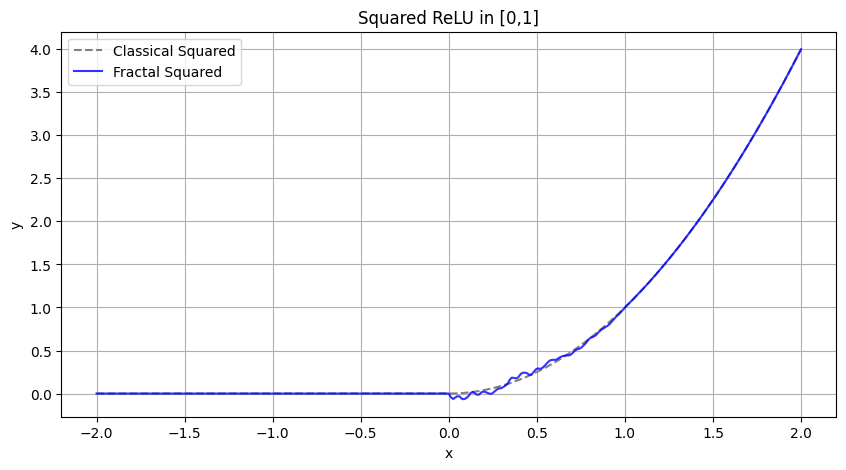

In [28]:
# 2. Squared ReLU plot
plt.figure(figsize=(10, 5))
plt.plot(x_vals.numpy(), classical_squared.numpy(), label='Classical Squared', color='gray', linestyle='--')
plt.plot(x_vals.numpy(), y_squared.numpy(), label='Fractal Squared', color='blue', alpha=0.8)
plt.title('Squared ReLU in [0,1]')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.show()

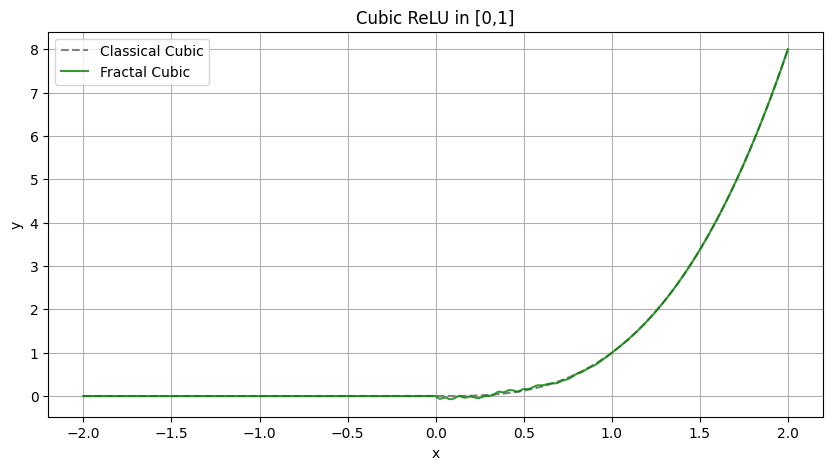

In [29]:
# 3. Cubic ReLU plot
plt.figure(figsize=(10, 5))
plt.plot(x_vals.numpy(), classical_cubic.numpy(), label='Classical Cubic', color='gray', linestyle='--')
plt.plot(x_vals.numpy(), y_cubic.numpy(), label='Fractal Cubic', color='green', alpha=0.8)
plt.title('Cubic ReLU in [0,1]')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.show()